# Unsupervised Learning for Finance: PCA + Isolation Forest for Fraud Detection




## 1. Setup

In [ ]:
!pip install -q scikit-learn matplotlib seaborn pandas numpy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, precision_recall_curve
)

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## 2. Simulate a credit-card transaction dataset


In [ ]:
def simulate_transactions(n_legit=5000, n_fraud=180, seed=42):
    rng = np.random.default_rng(seed)

    def add_correlated_features(base_df, rng):
        # Several of these are noisy variants of existing columns —
        # realistic (30-day spend tracks 7-day spend, hourly velocity tracks
        # daily velocity, etc.) and gives PCA real redundancy to compress.
        base_df["avg_amount_last_30days"] = (
            base_df["avg_amount_last_7days"] * rng.normal(1.05, 0.08, len(base_df))
        )
        base_df["num_txns_last_day"] = (
            base_df["num_txns_last_hour"] * rng.normal(9, 1.5, len(base_df))
        ).clip(0, None)
        base_df["merchant_category_risk"] = (
            base_df["merchant_risk_score"] * rng.normal(1.0, 0.12, len(base_df))
        ).clip(0, 100)
        base_df["geo_velocity_km_per_hr"] = (
            base_df["distance_from_last_txn_km"] * rng.normal(1.1, 0.2, len(base_df))
        ).clip(0, None)
        base_df["spend_to_income_ratio"] = (
            base_df["ratio_to_median_amount"] * rng.normal(0.9, 0.15, len(base_df))
        ).clip(0.05, None)
        return base_df

    # --- Legitimate transactions ---
    legit = pd.DataFrame({
        "amount": rng.gamma(shape=2.0, scale=35, size=n_legit),
        "transaction_hour": rng.normal(14, 4, n_legit).clip(0, 23),
        "merchant_risk_score": rng.beta(2, 8, n_legit) * 100,
        "num_txns_last_hour": rng.poisson(1.0, n_legit),
        "avg_amount_last_7days": rng.gamma(shape=2.2, scale=32, size=n_legit),
        "distance_from_home_km": rng.exponential(4, n_legit),
        "distance_from_last_txn_km": rng.exponential(2, n_legit),
        "ratio_to_median_amount": rng.normal(1.0, 0.25, n_legit).clip(0.1, None),
        "is_foreign_txn": rng.binomial(1, 0.03, n_legit),
        "account_age_days": rng.normal(900, 400, n_legit).clip(30, None),
    })
    legit = add_correlated_features(legit, rng)
    legit["is_fraud"] = 0

    # --- Fraudulent transactions: unusual along several axes at once ---
    fraud = pd.DataFrame({
        "amount": rng.gamma(shape=2.0, scale=180, size=n_fraud),
        "transaction_hour": rng.choice(
            list(range(0, 5)) + list(range(22, 24)), size=n_fraud
        ).astype(float),
        "merchant_risk_score": rng.beta(6, 2, n_fraud) * 100,
        "num_txns_last_hour": rng.poisson(6.0, n_fraud),
        "avg_amount_last_7days": rng.gamma(shape=2.0, scale=35, size=n_fraud),
        "distance_from_home_km": rng.exponential(220, n_fraud),
        "distance_from_last_txn_km": rng.exponential(180, n_fraud),
        "ratio_to_median_amount": rng.normal(4.5, 1.4, n_fraud).clip(1.5, None),
        "is_foreign_txn": rng.binomial(1, 0.55, n_fraud),
        "account_age_days": rng.normal(900, 400, n_fraud).clip(30, None),
    })
    fraud = add_correlated_features(fraud, rng)
    fraud["is_fraud"] = 1

    df = pd.concat([legit, fraud], ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)  # shuffle
    return df

df = simulate_transactions()
print(f"Total transactions: {len(df)}   |   Fraud rate: {df['is_fraud'].mean()*100:.2f}%")
print(f"Number of raw features: {df.shape[1] - 1}")
df.head()


Total transactions: 5180   |   Fraud rate: 3.47%
Number of raw features: 15


,amount,transaction_hour,merchant_risk_score,num_txns_last_hour,avg_amount_last_7days,distance_from_home_km,distance_from_last_txn_km,ratio_to_median_amount,is_foreign_txn,account_age_days,avg_amount_last_30days,num_txns_last_day,merchant_category_risk,geo_velocity_km_per_hr,spend_to_income_ratio,is_fraud
0,183.490859,12.954331,28.224988,0,77.176350,1.213728,0.512427,1.059786,0,1104.585383,87.415515,0.00000,24.461232,0.503742,1.034534,0
1,8.407219,13.299963,23.326239,3,129.384454,3.483384,1.159071,0.704582,0,1864.415688,165.521667,27.14388,20.230847,1.647644,0.675424,0
2,22.418084,14.165890,13.340325,4,41.173689,5.750732,1.833028,1.104649,0,1153.964134,49.918184,32.49426,13.648713,2.873945,0.772686,0
3,19.766788,15.243120,13.463767,0,35.891516,4.765921,0.647135,0.856050,0,1781.293510,31.425991,0.00000,15.436663,0.445105,0.761549,0
4,24.390371,18.336624,10.675826,0,34.359656,2.189391,4.881171,1.301130,0,1015.936061,35.140096,0.00000,9.909653,5.580604,0.892506,0


### Quick look at class balance and feature distributions

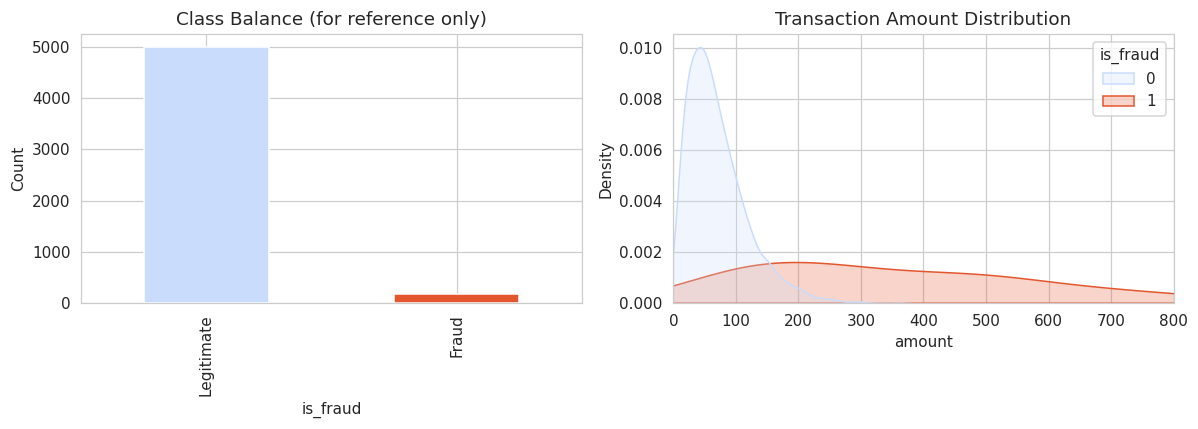

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["is_fraud"].value_counts().rename({0: "Legitimate", 1: "Fraud"}).plot(
    kind="bar", ax=axes[0], color=["#CADCFC", "#E4572E"]
)
axes[0].set_title("Class Balance (for reference only)")
axes[0].set_ylabel("Count")

sns.kdeplot(data=df, x="amount", hue="is_fraud", fill=True, common_norm=False,
            palette={0: "#CADCFC", 1: "#E4572E"}, ax=axes[1])
axes[1].set_xlim(0, 800)
axes[1].set_title("Transaction Amount Distribution")

plt.tight_layout()
plt.show()


## 3. Preprocess




In [ ]:
feature_cols = [c for c in df.columns if c != "is_fraud"]
X = df[feature_cols].values
y_true = df["is_fraud"].values  # held out — evaluation only

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix shape:", X_scaled.shape)


Scaled feature matrix shape: (5180, 15)


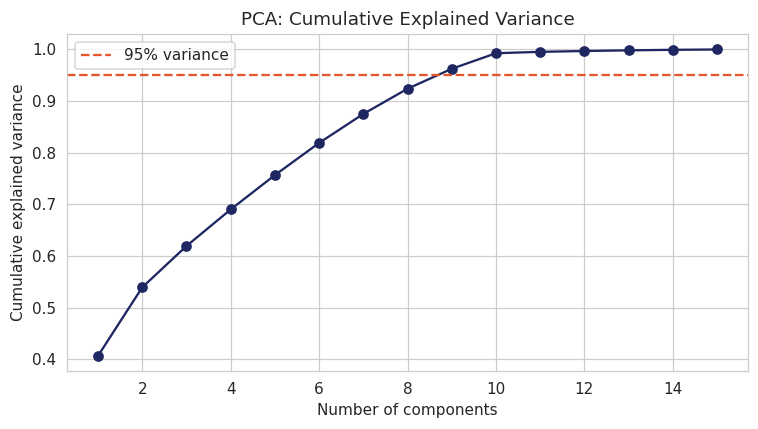

Components needed for 95% variance: 9


In [ ]:
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#1E2761")
plt.axhline(0.95, color="#E4572E", linestyle="--", label="95% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

n_components = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_components}")


In [ ]:
# Reduce to 2 components for the illustrative scatter plot used in the slides,
# and to n_components for the actual anomaly-detection model.
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_model = PCA(n_components=n_components, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

print("2D projection (for plotting):", X_pca_2d.shape)
print("Reduced feature space (for modeling):", X_pca.shape)


2D projection (for plotting): (5180, 2)
Reduced feature space (for modeling): (5180, 9)


### Visualize the PCA-reduced transactions

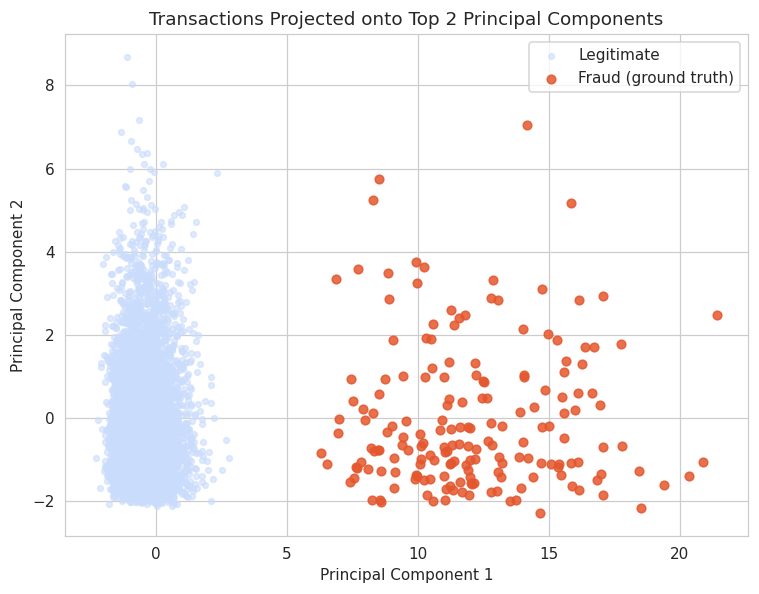

In [ ]:
plt.figure(figsize=(7, 5.5))
plt.scatter(X_pca_2d[y_true == 0, 0], X_pca_2d[y_true == 0, 1],
            s=14, alpha=0.6, color="#CADCFC", label="Legitimate")
plt.scatter(X_pca_2d[y_true == 1, 0], X_pca_2d[y_true == 1, 1],
            s=32, alpha=0.85, color="#E4572E", label="Fraud (ground truth)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Transactions Projected onto Top 2 Principal Components")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Anomaly detection with Isolation Forest



In [ ]:
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.035,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_pca)

# decision_function: higher = more normal. We flip sign so higher = more anomalous,
# matching the "anomaly score" framing used in the slides, and rescale to [0, 1].
raw_scores = -iso_forest.decision_function(X_pca)
anomaly_score = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

pred_anomaly = (iso_forest.predict(X_pca) == -1).astype(int)  # 1 = flagged as anomaly

df["anomaly_score"] = anomaly_score
df["predicted_fraud"] = pred_anomaly

print(f"Flagged {pred_anomaly.sum()} of {len(df)} transactions as anomalies "
      f"({pred_anomaly.mean()*100:.2f}%)")


Flagged 182 of 5180 transactions as anomalies (3.51%)


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      5000
       Fraud       0.93      0.94      0.94       180

    accuracy                           1.00      5180
   macro avg       0.97      0.97      0.97      5180
weighted avg       1.00      1.00      1.00      5180



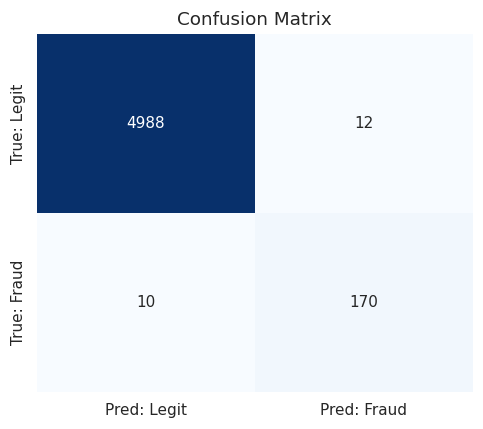

ROC-AUC (anomaly score vs. true label): 1.000


In [ ]:
print(classification_report(y_true, pred_anomaly, target_names=["Legitimate", "Fraud"]))

cm = confusion_matrix(y_true, pred_anomaly)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred: Legit", "Pred: Fraud"],
            yticklabels=["True: Legit", "True: Fraud"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

auc = roc_auc_score(y_true, anomaly_score)
print(f"ROC-AUC (anomaly score vs. true label): {auc:.3f}")


### Anomaly score distribution

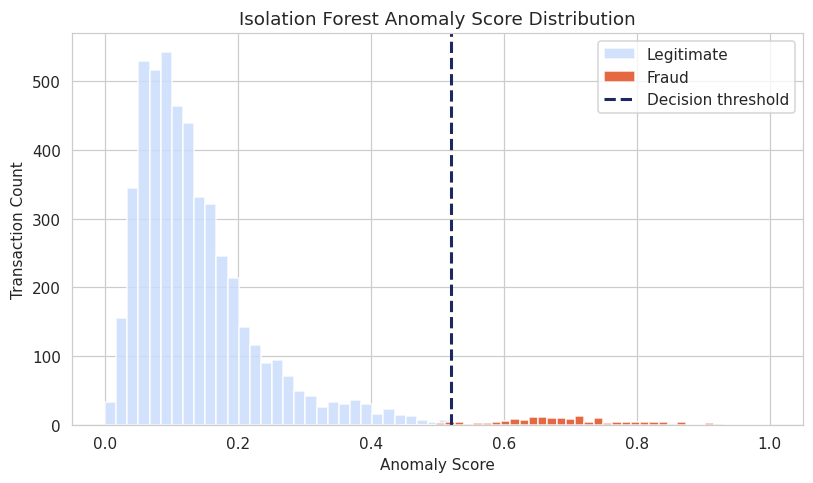

In [ ]:
threshold = np.quantile(anomaly_score, 1 - 0.035)  # matches ~contamination rate

plt.figure(figsize=(7.5, 4.5))
plt.hist(anomaly_score[y_true == 0], bins=40, alpha=0.85, color="#CADCFC", label="Legitimate")
plt.hist(anomaly_score[y_true == 1], bins=40, alpha=0.9, color="#E4572E", label="Fraud")
plt.axvline(threshold, color="#1E2761", linestyle="--", linewidth=2, label="Decision threshold")
plt.xlabel("Anomaly Score")
plt.ylabel("Transaction Count")
plt.title("Isolation Forest Anomaly Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()


### PCA scatter, colored by model prediction

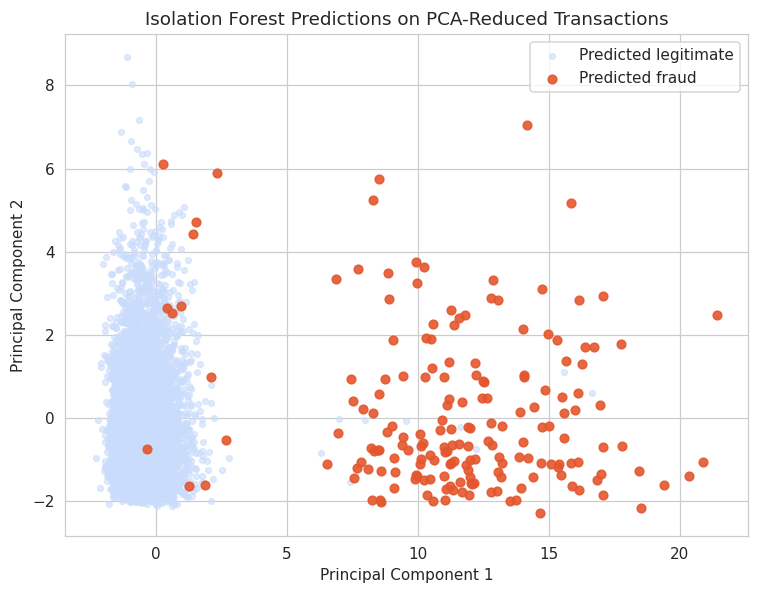

In [ ]:
plt.figure(figsize=(7, 5.5))
plt.scatter(X_pca_2d[pred_anomaly == 0, 0], X_pca_2d[pred_anomaly == 0, 1],
            s=14, alpha=0.6, color="#CADCFC", label="Predicted legitimate")
plt.scatter(X_pca_2d[pred_anomaly == 1, 0], X_pca_2d[pred_anomaly == 1, 1],
            s=32, alpha=0.9, color="#E4572E", label="Predicted fraud")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Predictions on PCA-Reduced Transactions")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
top_flagged = df.sort_values("anomaly_score", ascending=False).head(10)
top_flagged[feature_cols + ["is_fraud", "anomaly_score"]]


,amount,transaction_hour,merchant_risk_score,num_txns_last_hour,avg_amount_last_7days,distance_from_home_km,distance_from_last_txn_km,ratio_to_median_amount,is_foreign_txn,account_age_days,avg_amount_last_30days,num_txns_last_day,merchant_category_risk,geo_velocity_km_per_hr,spend_to_income_ratio,is_fraud,anomaly_score
734,198.303185,0.0,74.517504,9,154.451202,46.482469,731.184640,5.210081,1,980.116804,176.748718,73.260270,69.287938,960.524592,5.864211,1,1.000000
1899,567.012088,2.0,84.688667,3,39.518226,101.837739,1006.102321,4.072993,0,675.873865,41.381194,25.468159,67.901975,1073.087623,4.457827,1,0.930486
5074,419.435299,23.0,91.791058,1,32.607317,8.672592,680.561109,4.828562,0,1379.228764,31.517233,9.943666,100.000000,678.767845,4.817123,1,0.924242
1933,59.671684,23.0,77.443815,7,92.541954,57.011108,680.923244,4.246313,1,1115.909728,82.290895,86.627885,79.119831,683.208118,3.403597,1,0.917325
3550,898.251087,4.0,78.412950,10,245.877965,192.616825,3.171280,9.439745,0,1434.824199,270.607876,77.978801,71.557596,3.747433,7.507430,1,0.915921
5044,120.971370,3.0,96.109635,2,28.093176,253.342969,660.720045,4.596716,1,1508.038262,29.816347,16.765827,79.978300,988.937854,3.996989,1,0.907515
1395,1535.331508,1.0,61.038528,6,15.245964,247.315390,69.122415,4.757400,1,2022.509460,14.714626,46.409395,56.735473,76.367831,3.738213,1,0.903797
5025,128.258195,2.0,80.656918,6,80.310595,1082.954701,43.291235,4.701779,1,565.323521,88.152944,58.065696,79.333275,51.719360,3.846751,1,0.874874
1179,492.359524,23.0,84.303515,9,88.407937,722.571328,33.433975,3.588301,0,286.793316,98.165153,60.132674,88.703622,40.927946,3.798454,1,0.872338
3064,544.388529,23.0,69.098088,9,42.203803,59.972789,463.174743,4.041036,0,801.566262,43.355314,74.425003,66.472927,582.267315,2.718415,1,0.871622
